<a href="https://colab.research.google.com/github/Kendallfiliaggi/Technical-Portfolio/blob/main/Final_Exam_Coding_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Exam Coding Part (55 Points)
### Context:

The data is based on a real anonymized bank transactions and account info.
We'll work on the data cleaning, columns transformations, and other techniques that we've learned in the course.

### Dataset Description:
We'll work on three datasets (in three separate csv files):

**account**: each record describes static characteristics of an account

**transaction**: each record describes one transaction on an account

**district**: each record describes demographic characteristics of a district

In reality, the organizations like banks often have data stored in multiple datasets. Assume we want to study the transactional level data, we'll need to combine these three datasets together to have transactions data with account and district data.

### Objective:
Examine/clean the individual dataset

Combine them into a single dataset, which is subject to more cleaning

Create new columns based on existing columns

By the end, the new dataset is ready for more analysis.

# **Final Coding Exam**
by Kendall Filiaggi


11/3/2025

### 1. Import the libraries

In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

I uploaded the main set of libraries that we used throughout the semester for overall cleaning and merging. These libraries help in the data maipulation, analysis and visualization processes.




### 2. Import the data from three csv files as DataFrames account, district, trans
Hint: the read_csv function can automatically infer and load zip file, read its documentation of parameter compression if you are interested in details
you may ignore the warning when reading the trans.csv.zip file. It is optional to follow the warning instructions to remove it.

In [ ]:
import pandas as pd


ACCOUNT_PATH  = "/content/account.csv"
DISTRICT_PATH = "/content/district.csv"
TRANS_PATH    = "/content/trans.zip"


import os
def must_exist(p, friendly):
    if not os.path.exists(p):
        raise FileNotFoundError(
            f"Missing {friendly}: {p}\n"
        )

must_exist(ACCOUNT_PATH,  "account CSV")
must_exist(DISTRICT_PATH, "district CSV")
must_exist(TRANS_PATH,    "transactions ZIP")


account  = pd.read_csv(ACCOUNT_PATH)
district = pd.read_csv(DISTRICT_PATH)
trans    = pd.read_csv(TRANS_PATH, compression='infer')

/tmp/ipykernel_1893/943504000.py:23: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  trans    = pd.read_csv(TRANS_PATH, compression='infer')


In this step I uploaded the three data files required for this project: account, district, and transaction. I first had to convert them to CSVs when downloading. I used the must_exist() function to verify the data files were working properly before loading.

### 3. Look at the info summary, head of each DataFrame

In [ ]:
print("\n=== ACCOUNT.info() ===");  account.info()
print("\n=== ACCOUNT.head() ===");  display(account.head())

print("\n=== DISTRICT.info() ==="); district.info()
print("\n=== DISTRICT.head() ==="); display(district.head())

print("\n=== TRANS.info() ===");    trans.info()
print("\n=== TRANS.head() ===");    display(trans.head())


=== ACCOUNT.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   account_id         4500 non-null   int64 
 1   district_id        4500 non-null   int64 
 2   frequency          4500 non-null   object
 3   account_open_date  4500 non-null   object
 4   client_id          4500 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 175.9+ KB

=== ACCOUNT.head() ===


,account_id,district_id,frequency,account_open_date,client_id
0,576,55,MONTHLY STATEMENTS,1993-01-01,692
1,3818,74,MONTHLY STATEMENTS,1993-01-01,4601
2,704,55,MONTHLY STATEMENTS,1993-01-01,844
3,2378,16,MONTHLY STATEMENTS,1993-01-01,2873
4,2632,24,MONTHLY STATEMENTS,1993-01-02,3177



=== DISTRICT.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   district_id           76 non-null     int64  
 1   district_name         76 non-null     object 
 2   region                76 non-null     object 
 3   population            76 non-null     int64  
 4   average_salary        66 non-null     float64
 5   unemployment_rate     66 non-null     float64
 6   num_committed_crimes  67 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 4.3+ KB

=== DISTRICT.head() ===


,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,1,Hl.m. Praha,Prague,1204953,12541.0,0.43,99107.0
1,2,Benesov,central Bohemia,88884,NaN,NaN,2674.0
2,3,Beroun,central Bohemia,75232,8980.0,2.21,2813.0
3,4,Kladno,central Bohemia,149893,9753.0,5.05,NaN
4,5,Kolin,central Bohemia,95616,9307.0,4.43,NaN



=== TRANS.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   trans_id         1056320 non-null  int64  
 1   account_id       1056320 non-null  int64  
 2   date             1056320 non-null  object 
 3   type             1056320 non-null  object 
 4   operation_type   873206 non-null   object 
 5   amount           1056320 non-null  float64
 6   balance          1056320 non-null  float64
 7   description      574439 non-null   object 
 8   partner_bank     273508 non-null   object 
 9   partner_account  295389 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 80.6+ MB

=== TRANS.head() ===


,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,NaN,NaN,NaN
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,NaN,NaN,NaN
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,NaN,NaN,NaN
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,NaN,NaN,NaN
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,NaN,NaN,NaN


In order to look at the data, I used the .info() and .head() coding. This showed the data was uploaded correctly while showing any formatting issues or missing value.

### 4. Check for the unique values and their counts in each column for the three DataFrames and check whether there are duplicates in the datasets.

In [ ]:
def profile_uniques(df, name, max_cols=50):
    print(f"\n=== Unique values & value_counts for {name} ===")
    for col in df.columns[:max_cols]:
        vc = df[col].value_counts(dropna=False).head(10)
        print(f"\n[{name}.{col}] nunique={df[col].nunique(dropna=True)}  (showing top 10)")
        print(vc)

profile_uniques(account,  "account")
profile_uniques(district, "district")
profile_uniques(trans,    "trans")

print("\n=== Duplicate row counts ===")
print("account dup rows:",  account.duplicated().sum())
print("district dup rows:", district.duplicated().sum())
print("trans dup rows:",    trans.duplicated().sum())


=== Unique values & value_counts for account ===

[account.account_id] nunique=4500  (showing top 10)
account_id
3276    1
576     1
3818    1
704     1
703     1
3385    1
3187    1
1171    1
246     1
1177    1
Name: count, dtype: int64

[account.district_id] nunique=77  (showing top 10)
district_id
1     554
70    152
74    135
54    128
64     92
72     88
68     83
5      65
46     59
52     57
Name: count, dtype: int64

[account.frequency] nunique=3  (showing top 10)
frequency
MONTHLY STATEMENTS              4167
WEEKLY STATEMENTS                240
STATEMENTS AFTER TRANSACTION      93
Name: count, dtype: int64

[account.account_open_date] nunique=1535  (showing top 10)
account_open_date
1993-02-08    13
1993-10-08    12
1996-06-25    11
1996-11-24    11
1993-02-27    10
1996-07-08    10
1997-08-08    10
1993-06-08    10
1993-03-08     9
1996-01-01     9
Name: count, dtype: int64

[account.client_id] nunique=4500  (showing top 10)
client_id
3965    1
692     1
4601    1
844     

I looked for the unique values in each column and checked for duplicate rows using as you can see there were no dupliucate rows and some overlapping column headings. In order to do this I used the nunique and account.duplicated().sum()) coding.

### 5. Convert column account_open_date in account and column date in trans into datetime dtypes

In [ ]:
if 'account_open_date' in account.columns:
    account['account_open_date'] = pd.to_datetime(account['account_open_date'], errors='coerce')
else:
    print("WARN: 'account_open_date' not found in account. Check the column name (e.g., 'open_date').")

if 'date' in trans.columns:
    trans['date'] = pd.to_datetime(trans['date'], errors='coerce')
else:
    print("WARN: 'date' not found in trans. Check the transaction date column name.")

I used the pd.to_datetime() code to convert the the dates into dtypes as directed. I also used the errors='coerce' to turn incorrectly formatted dates into NaT so that no code is broken. The 'If' function makes sire the columns exists prior to converting.

### 6. Convert the columns region and district_name in district to all uppercase

In [ ]:
for col in ['region', 'district_name']:
    if col in district.columns:
        district[col] = district[col].astype(str).str.upper()
    else:
        print(f"WARN: '{col}' not found in district; skipping uppercase.")

In order to convert the columns region and district_name in district to all uppercase, i used the .astype(str).str.upper() code. I then followed with if statements to make sure teh columns exist once again. This is to make the code easy for users to use

### 7. Check for missing data by columns in "account" and "district" using the isna method and fill the missing vaue of using their averages



In [ ]:
def fill_numeric_with_mean(df, name):
    print(f"\n=== Missing by column BEFORE fill ({name}) ===")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    num_cols = df.select_dtypes(include=np.number).columns
    for c in num_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].mean())
    print(f"\n=== Missing by column AFTER fill ({name}) ===")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    return df

account  = fill_numeric_with_mean(account,  "account")
district = fill_numeric_with_mean(district, "district")


=== Missing by column BEFORE fill (account) ===
account_id           0
district_id          0
frequency            0
account_open_date    0
client_id            0
dtype: int64

=== Missing by column AFTER fill (account) ===
account_id           0
district_id          0
frequency            0
account_open_date    0
client_id            0
dtype: int64

=== Missing by column BEFORE fill (district) ===
average_salary          10
unemployment_rate       10
num_committed_crimes     9
region                   0
district_name            0
district_id              0
population               0
dtype: int64

=== Missing by column AFTER fill (district) ===
district_id             0
district_name           0
region                  0
population              0
average_salary          0
unemployment_rate       0
num_committed_crimes    0
dtype: int64


I checked for the missing values using the .isna().sum(). This showed how many nulls existed.
I then defined a function, fill_numeric_with_mean(), that identifies numeric columns with df.select_dtypes(include=np.number) and fills any missing values in those columns using .fillna(df[c].mean()), which replaces missing values with the column’s average.

### 8. Check for missing data by columns in trans using the isna method. Then, Divide the columns into numeric columns and categorical columns, then use the fillna method to fill numeric columns with -999, fill categorical columns with 'UNKNOWN'

In [ ]:
print("\n=== Missing by column in trans BEFORE fill ===")
print(trans.isna().sum().sort_values(ascending=False).head(25))

num_cols_trans  = trans.select_dtypes(include=np.number).columns
cat_cols_trans  = trans.select_dtypes(exclude=np.number).columns

trans[num_cols_trans] = trans[num_cols_trans].fillna(-999)
trans[cat_cols_trans] = trans[cat_cols_trans].fillna('UNKNOWN')

print("\n=== Missing by column in trans AFTER fill ===")
print(trans.isna().sum().sort_values(ascending=False).head(25))


=== Missing by column in trans BEFORE fill ===
partner_bank       782812
partner_account    760931
description        481881
operation_type     183114
account_id              0
trans_id                0
amount                  0
type                    0
date                    0
balance                 0
dtype: int64

=== Missing by column in trans AFTER fill ===
trans_id           0
account_id         0
date               0
type               0
operation_type     0
amount             0
balance            0
description        0
partner_bank       0
partner_account    0
dtype: int64


I used the .isna().sum() to check for missing values, then the select_dtypes to seperate the categorial and numeric columns. I then used the fillna() method as directed in the instructions.

### 9. Check for outliers in district using the describe method, then look at the histograms of the suspicious columns


=== district.describe() ===


,district_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
count,76.000000,76,76,7.600000e+01,76.000000,76.000000,76.000000
unique,NaN,76,8,NaN,NaN,NaN,NaN
top,NaN,HL.M. PRAHA,SOUTH MORAVIA,NaN,NaN,NaN,NaN
freq,NaN,1,14,NaN,NaN,NaN,NaN
mean,38.500000,NaN,NaN,1.336920e+05,8984.378788,3.836364,5164.567164
std,22.083176,NaN,NaN,1.378127e+05,728.220384,1.712588,11322.315513
min,1.000000,NaN,NaN,4.282100e+04,8110.000000,0.430000,888.000000
25%,19.750000,NaN,NaN,8.472500e+04,8533.750000,2.650000,2131.000000
50%,38.500000,NaN,NaN,1.083910e+05,8855.000000,3.836364,3178.000000
75%,57.250000,NaN,NaN,1.382770e+05,9127.500000,4.485000,5164.567164



=== Heuristic wide-range columns (top 8) ===
population              1162132.00
num_committed_crimes      98219.00
average_salary             4431.00
district_id                  75.00
unemployment_rate             8.97
dtype: float64


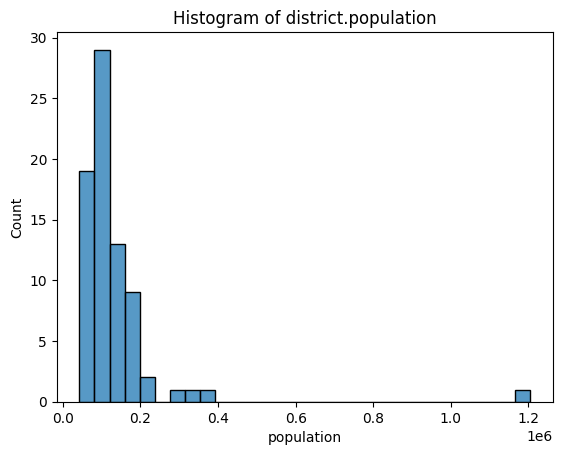

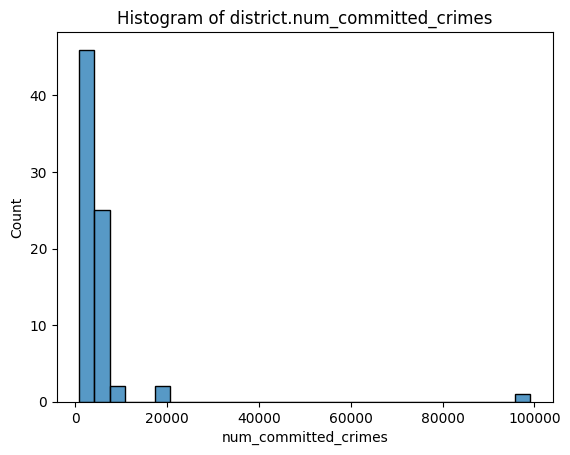

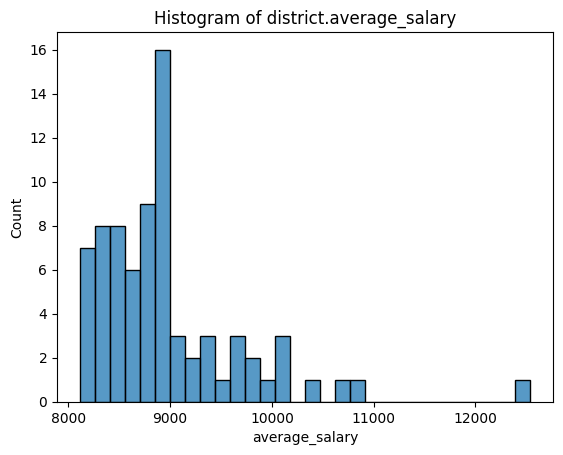

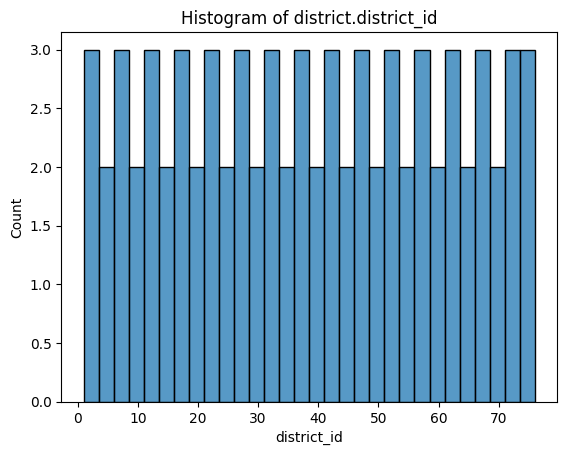

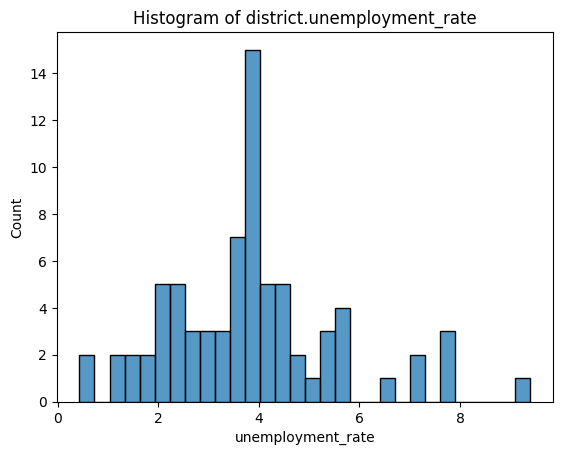

In [ ]:
print("\n=== district.describe() ===")
display(district.describe(include='all'))

num_cols_dist = district.select_dtypes(include=np.number).columns
ranges = (district[num_cols_dist].max() - district[num_cols_dist].min()).sort_values(ascending=False)
print("\n=== Heuristic wide-range columns (top 8) ===")
print(ranges.head(8))

suspect_cols = list(ranges.head(min(6, len(ranges))).index)

for c in suspect_cols:
    plt.figure()
    sns.histplot(district[c], bins=30, kde=False)
    plt.title(f"Histogram of district.{c}")
    plt.xlabel(c); plt.ylabel("Count")
    plt.show()

I used the describe method as directed, district.describe(include='all'), to check for outliers. I took the wide range data in suspect_cols to show any outliers within the columns. I plotted histograms to have. avisual repersenation of these potential outliers.

###10. Find the outliers in the dataset

In [ ]:
def iqr_outlier_mask(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (s < lo) | (s > hi)

outlier_report = {}
for c in num_cols_dist:
    mask = iqr_outlier_mask(district[c])
    n_out = int(mask.sum())
    if n_out > 0:
        outlier_report[c] = n_out

print("\n=== Outlier counts by numeric column (IQR rule) ===")
print(pd.Series(outlier_report).sort_values(ascending=False))


=== Outlier counts by numeric column (IQR rule) ===
average_salary          7
population              6
unemployment_rate       4
num_committed_crimes    4
dtype: int64


I created a function using the IQR to show any outliers by calculating the quarters. I stored this in th eoutlier report at the bottom.

### 11. Merge (left join) account and district into a new DataFrame called account_district using their common columns

In [ ]:
common_cols_ad = [c for c in account.columns if c in district.columns]
if not common_cols_ad:
    raise ValueError("No common columns between account and district. "
                     "Double-check the key names (e.g., 'district_id').")

print("\n=== Common columns for account ⟵ district (left join) ===")
print(common_cols_ad)

account_district = account.merge(district, how='left', on=common_cols_ad)


=== Common columns for account ⟵ district (left join) ===
['district_id']


I started off by indentifying the shared columns. I then used the account.merge(district, how='left', on=common_cols_ad) to perform a left join. This then created the new account district dataframe

###12. Check the information summary of account_district, any missing data? Then, Find the rows with missing data in account_district

In [ ]:
print("\n=== account_district.info() ===")
account_district.info()

print("\n=== Missing by column in account_district ===")
miss_cols = account_district.isna().sum()
print(miss_cols[miss_cols > 0].sort_values(ascending=False))

rows_with_na = account_district[account_district.isna().any(axis=1)]
print("\n=== Rows with any missing values in account_district (showing top 5) ===")
display(rows_with_na.head())


=== account_district.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            4500 non-null   int64         
 1   district_id           4500 non-null   int64         
 2   frequency             4500 non-null   object        
 3   account_open_date     4500 non-null   datetime64[ns]
 4   client_id             4500 non-null   int64         
 5   district_name         4460 non-null   object        
 6   region                4460 non-null   object        
 7   population            4460 non-null   float64       
 8   average_salary        4460 non-null   float64       
 9   unemployment_rate     4460 non-null   float64       
 10  num_committed_crimes  4460 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 386.8+ KB

=== Missing by column 

,account_id,district_id,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
5,1972,77,MONTHLY STATEMENTS,1993-01-02,2397,NaN,NaN,NaN,NaN,NaN,NaN
77,1000,77,MONTHLY STATEMENTS,1993-01-25,1204,NaN,NaN,NaN,NaN,NaN,NaN
308,299,77,MONTHLY STATEMENTS,1993-04-05,364,NaN,NaN,NaN,NaN,NaN,NaN
322,8321,77,MONTHLY STATEMENTS,1993-04-12,10275,NaN,NaN,NaN,NaN,NaN,NaN
394,551,77,MONTHLY STATEMENTS,1993-05-07,664,NaN,NaN,NaN,NaN,NaN,NaN


I used account_district.info() to make sure everything merged correctly. I then calculated any values that were missing using the .isna.sum and printed the nonzero ones. I filtered for rows containing at least one missing value using account_district.isna.anyaxis=1. This showed me wich records needed cleaning.

###13. Drop the rows with missing values

In [ ]:
account_district_clean = account_district.dropna().copy()
print("\n=== account_district_clean shape (after dropna) ===", account_district_clean.shape)


=== account_district_clean shape (after dropna) === (4460, 11)


I removed the missing value rows using .dropna and saved the new data under account_district_clean.

### 14. Merge (left join) trans and account_district into a new DataFrame called all_data using their common columns

In [ ]:
common_cols_tad = [c for c in trans.columns if c in account_district_clean.columns]
if not common_cols_tad:
    raise ValueError("No common columns between trans and account_district_clean. "
                     "Double-check shared keys (e.g., 'account_id').")

print("\n=== Common columns for trans ⟵ account_district_clean (left join) ===")
print(common_cols_tad)

all_data = trans.merge(account_district_clean, how='left', on=common_cols_tad)

print("\n=== all_data.info() ===")
all_data.info()
display(all_data.head())



=== Common columns for trans ⟵ account_district_clean (left join) ===
['account_id']

=== all_data.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   trans_id              1056320 non-null  int64         
 1   account_id            1056320 non-null  int64         
 2   date                  1056320 non-null  datetime64[ns]
 3   type                  1056320 non-null  object        
 4   operation_type        1056320 non-null  object        
 5   amount                1056320 non-null  float64       
 6   balance               1056320 non-null  float64       
 7   description           1056320 non-null  object        
 8   partner_bank          1056320 non-null  object        
 9   partner_account       1056320 non-null  float64       
 10  district_id           1046264 non-null  float64    

,trans_id,account_id,date,type,operation_type,amount,balance,description,partner_bank,partner_account,district_id,frequency,account_open_date,client_id,district_name,region,population,average_salary,unemployment_rate,num_committed_crimes
0,695247,2378,1993-01-01,CREDIT,CREDIT IN CASH,700.0,700.0,UNKNOWN,UNKNOWN,-999.0,16.0,MONTHLY STATEMENTS,1993-01-01,2873.0,JINDRICHUV HRADEC,SOUTH BOHEMIA,93931.0,8427.000000,1.54,1913.0
1,171812,576,1993-01-01,CREDIT,CREDIT IN CASH,900.0,900.0,UNKNOWN,UNKNOWN,-999.0,55.0,MONTHLY STATEMENTS,1993-01-01,692.0,BRNO - VENKOV,SOUTH MORAVIA,157042.0,8984.378788,2.43,3894.0
2,207264,704,1993-01-01,CREDIT,CREDIT IN CASH,1000.0,1000.0,UNKNOWN,UNKNOWN,-999.0,55.0,MONTHLY STATEMENTS,1993-01-01,844.0,BRNO - VENKOV,SOUTH MORAVIA,157042.0,8984.378788,2.43,3894.0
3,1117247,3818,1993-01-01,CREDIT,CREDIT IN CASH,600.0,600.0,UNKNOWN,UNKNOWN,-999.0,74.0,MONTHLY STATEMENTS,1993-01-01,4601.0,OSTRAVA - MESTO,NORTH MORAVIA,323870.0,10673.000000,5.44,18347.0
4,579373,1972,1993-01-02,CREDIT,CREDIT IN CASH,400.0,400.0,UNKNOWN,UNKNOWN,-999.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I started off by finding the shared colums. Then I used the trans.merge(..., how='left', on=common_cols_tad) code to left join merge.

### 15.Create a new column account_open_year and assign it as the year from column account_open_date

In [ ]:
if 'account_open_date' in all_data.columns:
    all_data['account_open_year'] = all_data['account_open_date'].dt.year
else:
    print("WARN: 'account_open_date' not present in all_data (check earlier steps).")

In order to created the new column and assign it as the year from column account_open_date i used the .dt.year code and the if code to check it.

### 16. Calculate the difference between columns date (transaction date) and account_open_date & 17. Create a new column account_age_days and assign it as the difference in days between columns date (transaction date) and account_open_date

In [ ]:
if 'date' in all_data.columns and 'account_open_date' in all_data.columns:
    all_data['date_minus_open'] = all_data['date'] - all_data['account_open_date']
    all_data['account_age_days'] = all_data['date_minus_open'].dt.days
else:
    print("WARN: Need both 'date' and 'account_open_date' in all_data for age computations.")

I combined steps 16 and 17 into one block of code. I started off by subtracting and created a new column called date_minus_open. A timedelta was then created. I then finished the directions using the .dt.days code to convert the difference in numneric value and saved it as account_age_days.

### 18. use pd.qcut to create a new column amount_category by cutting the column amount into 3 equal-sized bins, and label the bins as 'low_amount', 'medium_amount', 'high_amount'

In [ ]:
if 'amount' in all_data.columns:
    try:
        all_data['amount_category'] = pd.qcut(all_data['amount'],
                                              q=3,
                                              labels=['low_amount','medium_amount','high_amount'])
    except ValueError as e:

        print("NOTE: pd.qcut encountered a ValueError (often due to duplicate bin edges). "
              "Falling back to rank-based qcut.")
        ranks = all_data['amount'].rank(method='first')
        all_data['amount_category'] = pd.qcut(ranks, q=3,
                                              labels=['low_amount','medium_amount','high_amount'])
else:
    print("WARN: Column 'amount' not found; cannot create amount_category.")

I used pd.qcut() to divide the amount column into three equal-sized groups and created a new categories shown above. For user friendliness I added a try/except code incase qcut fails as well as the if function to check the columns exists.  

### 19. Use pd.cut to create a new column account_age_days_category by cutting the column account_age_days into 5 equal-width bins

In [ ]:
if 'account_age_days' in all_data.columns:
    all_data['account_age_days_category'] = pd.cut(all_data['account_age_days'], bins=5)
else:
    print("WARN: 'account_age_days' not found; ensure Step 16–17 succeeded.")

print("\n=== Preview of engineered columns ===")
cols_to_show = [c for c in [
    'account_open_date','account_open_year','date','date_minus_open','account_age_days',
    'amount','amount_category','account_age_days_category'
] if c in all_data.columns]
display(all_data[cols_to_show].head(10))

print("\nDONE — Your combined dataset `all_data` is ready for analysis!")


=== Preview of engineered columns ===


,account_open_date,account_open_year,date,date_minus_open,account_age_days,amount,amount_category,account_age_days_category
0,1993-01-01,1993.0,1993-01-01,0 days,0.0,700.0,medium_amount,"(-2.19, 438.0]"
1,1993-01-01,1993.0,1993-01-01,0 days,0.0,900.0,medium_amount,"(-2.19, 438.0]"
2,1993-01-01,1993.0,1993-01-01,0 days,0.0,1000.0,medium_amount,"(-2.19, 438.0]"
3,1993-01-01,1993.0,1993-01-01,0 days,0.0,600.0,medium_amount,"(-2.19, 438.0]"
4,NaT,NaN,1993-01-02,NaT,NaN,400.0,medium_amount,NaN
5,1993-01-02,1993.0,1993-01-02,0 days,0.0,1100.0,medium_amount,"(-2.19, 438.0]"
6,1993-01-03,1993.0,1993-01-03,0 days,0.0,600.0,medium_amount,"(-2.19, 438.0]"
7,1993-01-03,1993.0,1993-01-03,0 days,0.0,1100.0,medium_amount,"(-2.19, 438.0]"
8,1993-01-03,1993.0,1993-01-03,0 days,0.0,200.0,low_amount,"(-2.19, 438.0]"
9,1993-01-03,1993.0,1993-01-03,0 days,0.0,800.0,medium_amount,"(-2.19, 438.0]"



DONE — Your combined dataset `all_data` is ready for analysis!


In the final step, i used the pd.cut code to create the 5 bins. This then created the final all_data to end the code.